In [103]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [104]:
df=pd.read_csv('/Users/ashish/Desktop/House-Price-Prediction/final_housing.csv')

In [105]:
df.head(10)

,Unnamed: 0,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,zipcode,lat,long,renovated
0,0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,98178,47.5112,-122.257,0
1,1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,98125,47.7210,-122.319,1
2,2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,98028,47.7379,-122.233,0
3,3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,98136,47.5208,-122.393,0
4,4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,98074,47.6168,-122.045,0
5,5,1225000.0,4,4.50,5420,101930,1.0,0,0,3,11,3890,1530,2001,98053,47.6561,-122.005,0
6,6,257500.0,3,2.25,1715,6819,2.0,0,0,3,7,1715,0,1995,98003,47.3097,-122.327,0
7,7,291850.0,3,1.50,1060,9711,1.0,0,0,3,7,1060,0,1963,98198,47.4095,-122.315,0
8,8,229500.0,3,1.00,1780,7470,1.0,0,0,3,7,1050,730,1960,98146,47.5123,-122.337,0
9,9,323000.0,3,2.50,1890,6560,2.0,0,0,3,7,1890,0,2003,98038,47.3684,-122.031,0


In [93]:
X=df.loc[:,"sqft_living"]
y=df.loc[:,"price"]

/Users/ashish/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


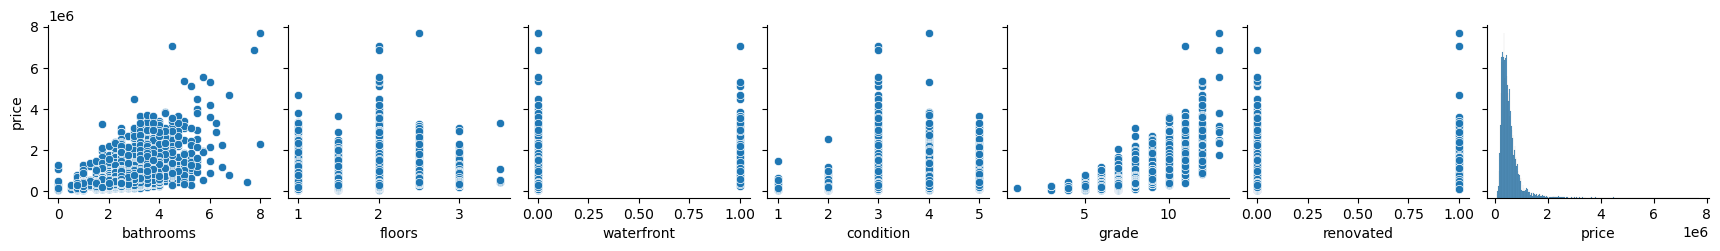

In [92]:
variables=["bathrooms","floors","waterfront","condition","grade","renovated","price"]
dataframe=df.loc[:,variables]
sns.pairplot(dataframe,y_vars="price")

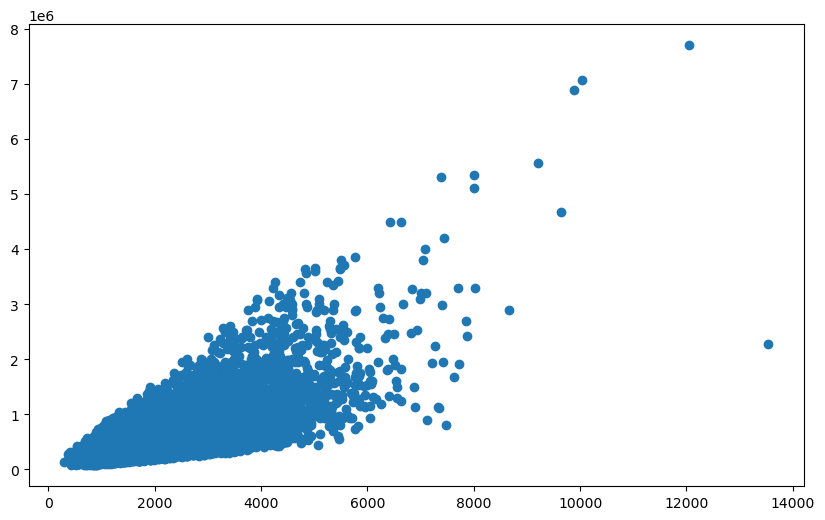

In [10]:
plt.figure(figsize=(10,6))
plt.scatter(X,y)
plt.show()

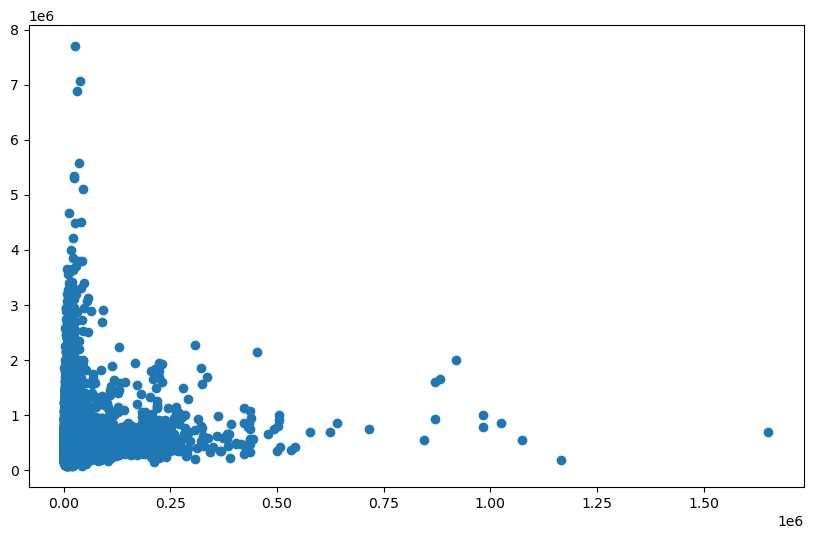

In [35]:
X1=df.loc[:,"sqft_lot"]
plt.figure(figsize=(10,6))
plt.scatter(X1,y)
plt.show()

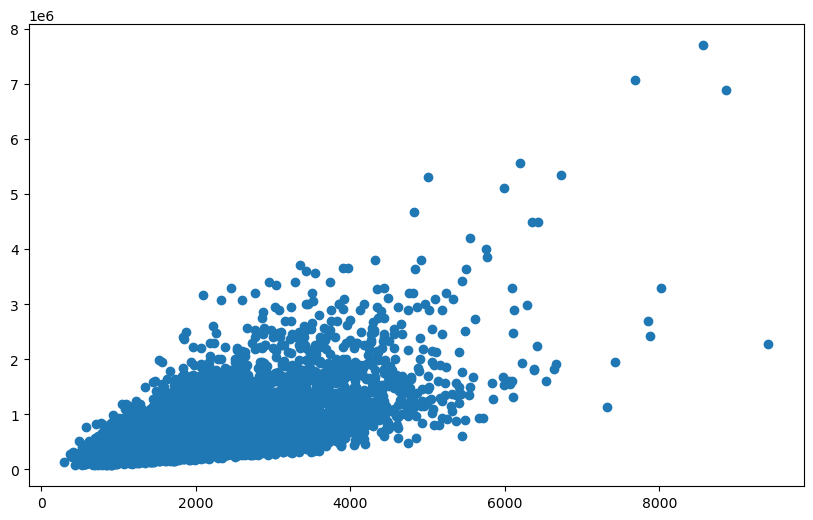

In [36]:
X2=df.loc[:,"sqft_above"]
plt.figure(figsize=(10,6))
plt.scatter(X2,y)
plt.show()

In [15]:
print(df['grade'].value_counts())

grade
7     8981
8     6068
9     2615
6     2038
10    1134
11     399
5      242
12      90
4       29
13      13
3        3
1        1
Name: count, dtype: int64


In [48]:
values_1=df['price'].groupby(df['grade']).mean()

In [49]:
values_1

grade
1     1.420000e+05
3     2.056667e+05
4     2.143810e+05
5     2.485240e+05
6     3.019196e+05
7     4.025903e+05
8     5.428528e+05
9     7.735132e+05
10    1.071771e+06
11    1.496842e+06
12    2.191222e+06
13    3.709615e+06
Name: price, dtype: float64

[ 1  2  3  4  5  6  7  8  9 10 11 12 13]
[ 1  3  4  5  6  7  8  9 10 11 12 13]


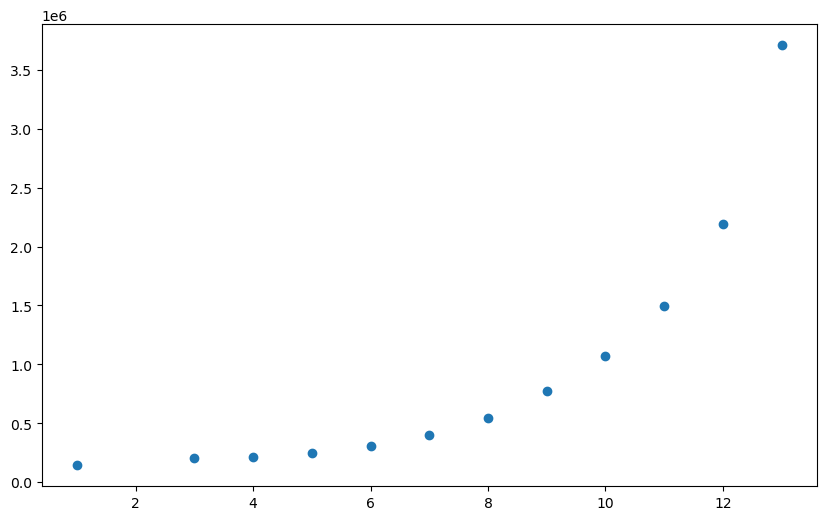

In [63]:
#the following chart clearly shows the increase in grading leads to increase price(explonentially), there's no grade 2 house
X3=np.arange(1,14)
print(X3)
X3=np.delete(X3,1)
print(X3)
y2=values_1.to_numpy()
plt.figure(figsize=(10,6))
plt.scatter(X3,y2)
plt.show()

In [64]:
print(df['condition'].value_counts())
values_2=df['price'].groupby(df['condition']).mean()
print(values_2)

condition
3    14031
4     5679
5     1701
2      172
1       30
Name: count, dtype: int64
condition
1    334431.666667
2    327287.145349
3    542012.578148
4    521200.390033
5    612418.089359
Name: price, dtype: float64


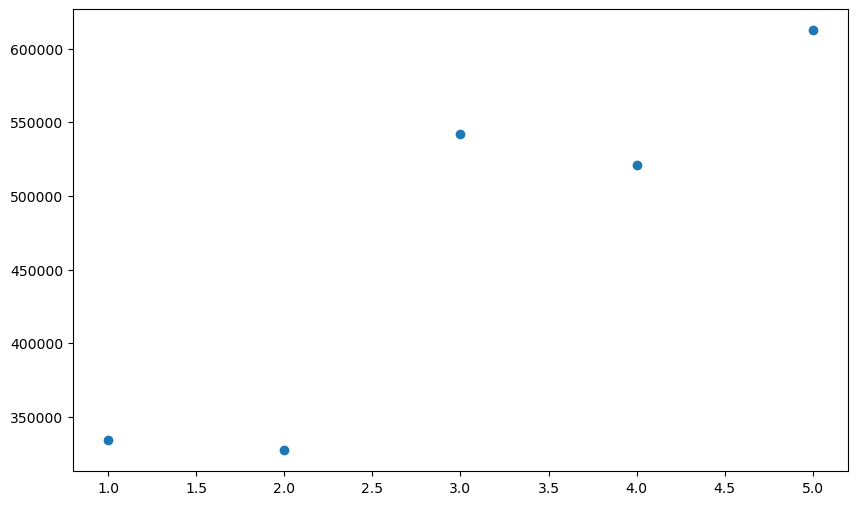

In [56]:
x3=np.arange(1,6)
plt.figure(figsize=(10,6))
plt.scatter(x3,values_2)
plt.show()

In [ ]:
#the following shows that there's 70 unique pincode in the dataset

In [124]:
df['zipcode'].unique()

98001

In [125]:
df['zipcode'].unique().min()

98001

In [126]:
df['zipcode'].unique().max()

98199

In [136]:
#now lets find the correlation between pincode and housing price, seeing the influence on the prices we should use zipcodes as a categorical variable using label encoding

In [137]:
prices_zipcode=df['price'].groupby(df['zipcode']).mean()

In [138]:
zipCodes=sorted(df['zipcode'].unique())

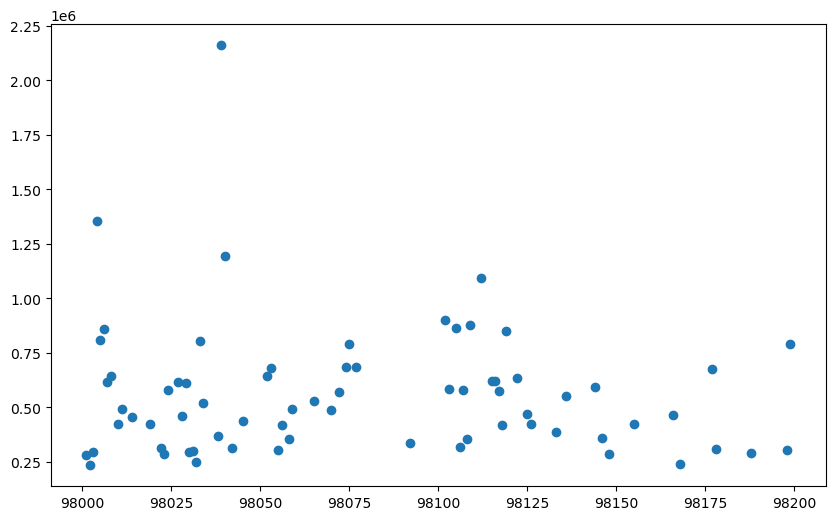

In [139]:
plt.figure(figsize=(10,6))
plt.scatter(zipCodes,prices_zipcode)
plt.show()

In [144]:
yearsBuilt=sorted(df['yr_built'].unique())

In [145]:
price_yearbuilt=df['price'].groupby(df['yr_built']).mean()

In [146]:
price_yearbuilt

yr_built
1900    581387.206897
1901    556935.931034
1902    673007.407407
1903    480958.195652
1904    583756.644444
            ...      
2011    544522.000000
2012    527447.335294
2013    678545.452736
2014    683681.754919
2015    759785.157895
Name: price, Length: 116, dtype: float64